--- TRAINING MODELS ---
Bagging Completed. Accuracy: 0.9561
AdaBoost Completed. Accuracy: 0.9649
GradientBoost Completed. Accuracy: 0.9561
Stacking Completed. Accuracy: 0.9737

--- FINAL COMPARISON ---
               Accuracy        F1
Bagging        0.956140  0.941176
AdaBoost       0.964912  0.952381
GradientBoost  0.956140  0.941176
Stacking       0.973684  0.964706


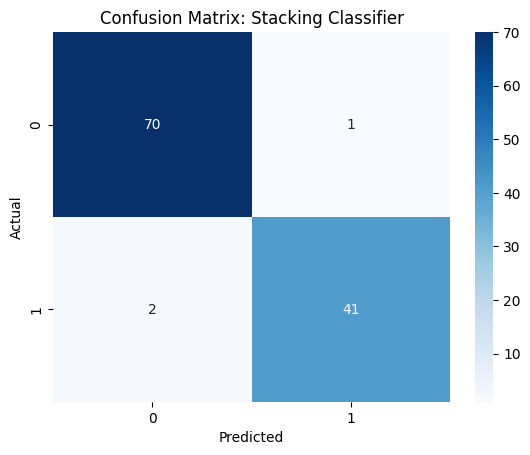

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]
df = pd.read_csv('wdbcdata.csv', header=None, names=columns)

df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

X = df.drop(['ID', 'Diagnosis'], axis=1)
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)


adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)


gboost_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)


base_learners = [
    ('dt', DecisionTreeClassifier(max_depth=3)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('lr', LogisticRegression(max_iter=1000))
]
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5
)


models = {
    "Bagging": bagging_model,
    "AdaBoost": adaboost_model,
    "GradientBoost": gboost_model,
    "Stacking": stacking_model
}

results = {}

print("--- TRAINING MODELS ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'Accuracy': acc, 'F1': f1}

    print(f"{name} Completed. Accuracy: {acc:.4f}")


results_df = pd.DataFrame(results).T
print("\n--- FINAL COMPARISON ---")
print(results_df)

y_pred_stack = stacking_model.predict(X_test)
sns.heatmap(confusion_matrix(y_test, y_pred_stack), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Stacking Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()